In [1]:
# import packages

import math
import csv
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.stats import spearmanr
import itertools

In [2]:
# define functions and classes

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()
    
def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

class EcodDomain:
    """Class for working with ECOD domains."""

    def __init__(self, ecod_line):
        self.uid = ecod_line.split('\t')[0]
        self.ecod_domain_id = ecod_line.split('\t')[1]
        self.f_id = ecod_line.split('\t')[3]
        self.pdb = ecod_line.split('\t')[4]
        self.chain = ecod_line.split('\t')[5]
        #self.pdb_range = self.parse_ecod_range(ecod_line.split('\t')[6])
        self.seqid_range = ecod_line.split('\t')[7]
        self.arch_name = ecod_line.split('\t')[9]
        self.x_name = ecod_line.split('\t')[10]
        self.h_name = ecod_line.split('\t')[11]
        self.t_name = ecod_line.split('\t')[12]
        self.f_name = ecod_line.split('\t')[13]
        self.asm_status = ecod_line.split('\t')[14]
        self.ligand = ecod_line.split('\t')[15].replace('NO_LIGANDS_4A',
                                                        '').split(',')

In [6]:
# locate assets

d_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv'
d_bac_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv'
d_arc_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv'

fo_path = '../data/assets/xgroup2/xgroup2foAveNONE.csv'
r_path = '../data/assets/xgroup2/xgroup2repetitiveness_v1.json'
co_path = '../data/assets/xgroup2/xgroup2contact_order_v1.json'
fc_path = '../data/assets/xgroup2/xgroup2fgroup_count_v1.json'
theme_path = '../data/assets/xgroup2/xgroup2theme_connections_v1.json'

In [7]:
# import data

xgroup2dist = csv2dict(d_path)
print(len(xgroup2dist))

xgroup2dist_bac = csv2dict(d_bac_path)
print(len(xgroup2dist_bac))  

xgroup2dist_arc = csv2dict(d_arc_path)
print(len(xgroup2dist_arc))

xgroup2foAveNONEAveNONE = csv2dict(fo_path)
print(len(xgroup2foAveNONEAveNONE)) 
    
with open(co_path, 'r') as file:
    xgroup2co = json.load(file)
print(len(xgroup2co))


with open(fc_path, 'r') as file:
    xgroup2fc = json.load(file)
print(len(xgroup2fc))
  

with open(theme_path, 'r') as file:
    xgroup2theme = json.load(file)
print(len(xgroup2theme))
      

with open(r_path, 'r') as file:
    xgroup2repetitiveness = json.load(file)
print(len(xgroup2repetitiveness))

2230
2230
2230
397
661
2431
2458
379


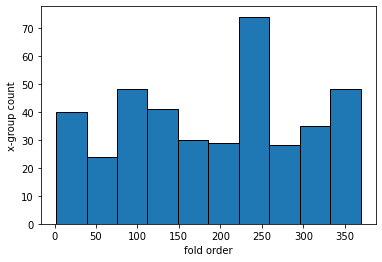

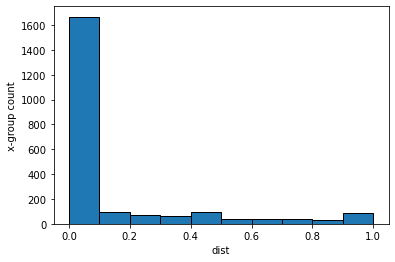

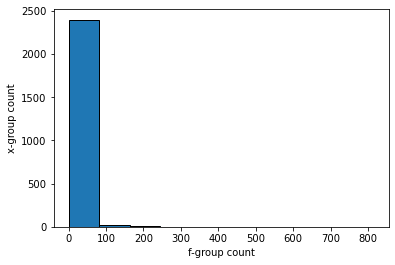

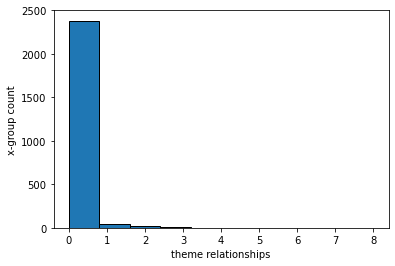

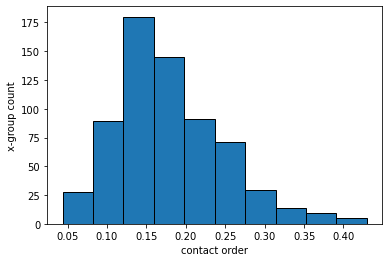

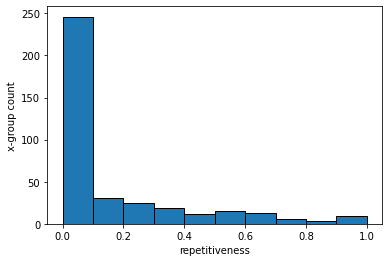

In [11]:
# Histograms

histogram(xgroup2foAveNONE, x_axis ='fold order', y_axis='x-group count')
histogram(xgroup2dist, x_axis ='dist', y_axis='x-group count')
histogram(xgroup2fc, x_axis ='f-group count', y_axis='x-group count')
histogram(xgroup2theme, x_axis ='theme relationships', y_axis='x-group count')
histogram(xgroup2co, x_axis ='contact order', y_axis='x-group count')
histogram(xgroup2repetitiveness, x_axis ='repetitiveness', y_axis='x-group count')

# Spearman correlations

fold order vs. dist score:  p_value = 4.51384975618518e-28


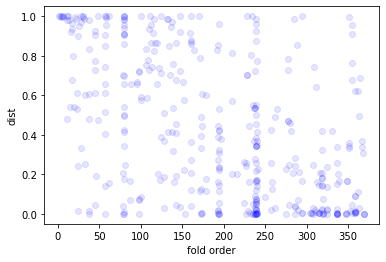

fold order vs. dist score bacteria:  p_value = 2.4134681641528676e-28


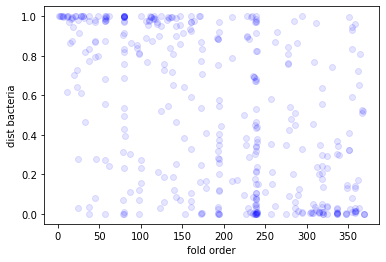

fold order vs. dist score archaea:  p_value = 6.869248808069266e-25


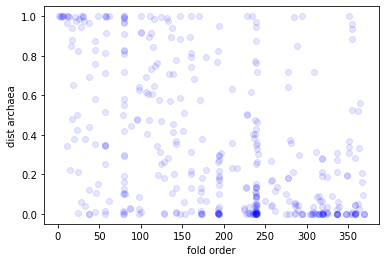

fold order vs. f-group count:  p_value = 2.415787632738986e-16


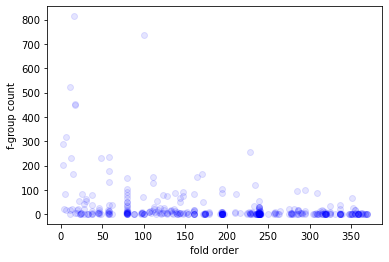

fold order vs. theme count:  p_value = 2.031783919783432e-09


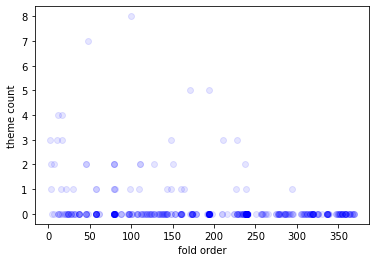

fold order vs. contact order:  p_value = 0.2744816562640689


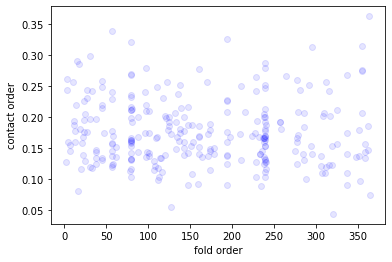

fold order vs. repetitiveness:  p_value = 0.5062930098485734


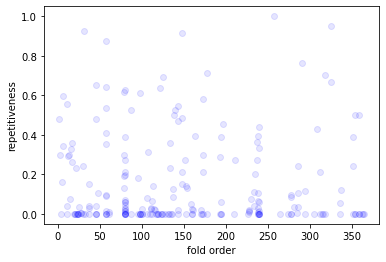

dist score vs. f-group count:  p_value = 3.3011261311268505e-90


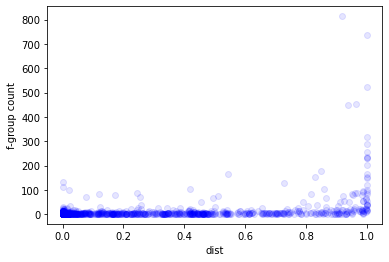

dist score vs. theme count:  p_value = 1.526392867329028e-17


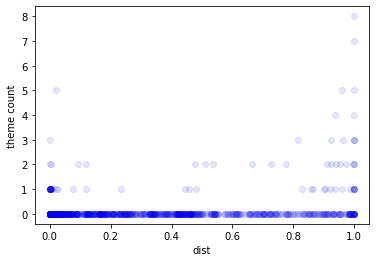

dist score vs. contact order:  p_value = 0.4640364876604699


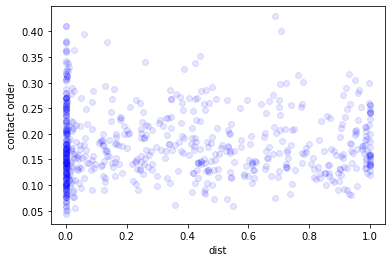

dist score vs. repetitiveness:  p_value = 3.2863243357344047e-09


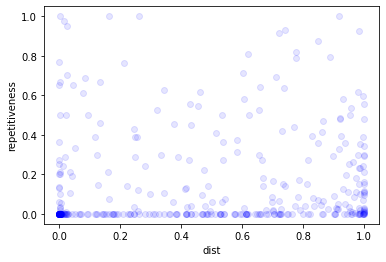

f-group count, theme count:  p_value = 4.581971385412601e-33


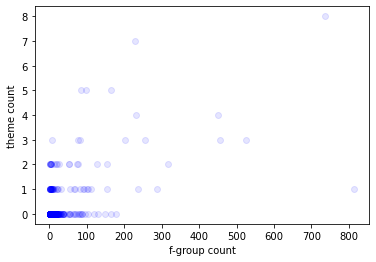

f-group count, contact order:  p_value = 0.011698446921340281


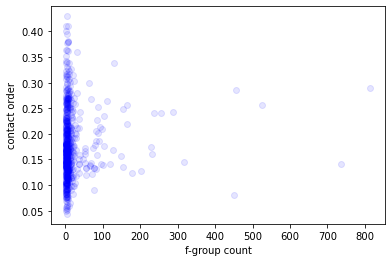

f-group count vs. repetitiveness:  p_value = 2.0667090322228135e-05


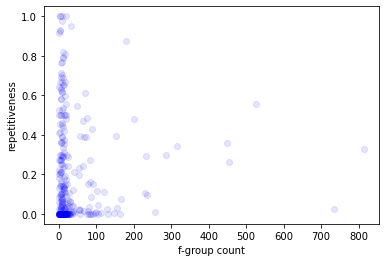

theme count, contact order:  p_value = 0.3039100928772361


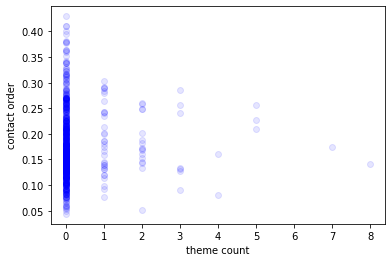

theme count vs. repetitiveness:  p_value = 0.05779157347762034


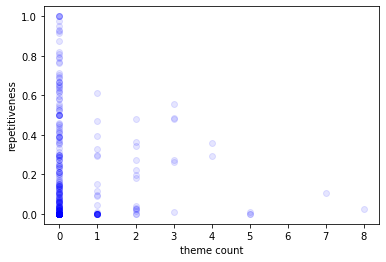

contact order vs. repetitiveness:  p_value = 0.08547108218845051


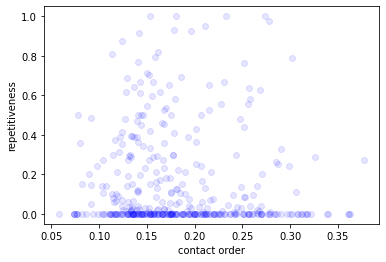

In [12]:
# fold order vs. XXX

corr, p = spearman(xgroup2foAveNONE, xgroup2dist)
print(f'fold order vs. dist score:  p_value = {p}')
scatter(xgroup2foAveNONE, xgroup2dist, 'fold order', 'dist')

corr, p = spearman(xgroup2foAveNONE, xgroup2dist_bac)
print(f'fold order vs. dist score bacteria:  p_value = {p}')
scatter(xgroup2foAveNONE, xgroup2dist_bac, 'fold order', 'dist bacteria')

corr, p = spearman(xgroup2foAveNONE, xgroup2dist_arc)
print(f'fold order vs. dist score archaea:  p_value = {p}')
scatter(xgroup2foAveNONE, xgroup2dist_arc, 'fold order', 'dist archaea')

corr, p = spearman(xgroup2foAveNONE, xgroup2fc)
print(f'fold order vs. f-group count:  p_value = {p}')
scatter(xgroup2foAveNONE, xgroup2fc, 'fold order', 'f-group count')

corr, p = spearman(xgroup2foAveNONE, xgroup2theme)
print(f'fold order vs. theme count:  p_value = {p}')
scatter(xgroup2foAveNONE, xgroup2theme, 'fold order', 'theme count')

corr, p = spearman(xgroup2foAveNONE, xgroup2co)
print(f'fold order vs. contact order:  p_value = {p}')
scatter(xgroup2foAveNONE, xgroup2co, 'fold order', 'contact order')

corr, p = spearman(xgroup2foAveNONE, xgroup2repetitiveness)
print(f'fold order vs. repetitiveness:  p_value = {p}')
scatter(xgroup2foAveNONE, xgroup2repetitiveness, 'fold order', 'repetitiveness')


# distribution score vs. XXX


corr, p = spearman(xgroup2dist, xgroup2fc)
print(f'dist score vs. f-group count:  p_value = {p}')
scatter(xgroup2dist, xgroup2fc, 'dist', 'f-group count')

corr, p = spearman(xgroup2dist, xgroup2theme)
print(f'dist score vs. theme count:  p_value = {p}')
scatter(xgroup2dist, xgroup2theme, 'dist', 'theme count')

corr, p = spearman(xgroup2dist, xgroup2co)
print(f'dist score vs. contact order:  p_value = {p}')
scatter(xgroup2dist, xgroup2co, 'dist', 'contact order')

corr, p = spearman(xgroup2dist, xgroup2repetitiveness)
print(f'dist score vs. repetitiveness:  p_value = {p}')
scatter(xgroup2dist, xgroup2repetitiveness, 'dist', 'repetitiveness')


# f-group count vs. XXX

corr, p = spearman(xgroup2fc, xgroup2theme)
print(f'f-group count, theme count:  p_value = {p}')
scatter(xgroup2fc, xgroup2theme, 'f-group count', 'theme count')

corr, p = spearman(xgroup2fc, xgroup2co)
print(f'f-group count, contact order:  p_value = {p}')
scatter(xgroup2fc, xgroup2co, 'f-group count', 'contact order')

corr, p = spearman(xgroup2fc, xgroup2repetitiveness)
print(f'f-group count vs. repetitiveness:  p_value = {p}')
scatter(xgroup2fc, xgroup2repetitiveness, 'f-group count', 'repetitiveness')


# theme count vs. XXX

corr, p = spearman(xgroup2theme, xgroup2co)
print(f'theme count, contact order:  p_value = {p}')
scatter(xgroup2theme, xgroup2co, 'theme count', 'contact order')

corr, p = spearman(xgroup2theme, xgroup2repetitiveness)
print(f'theme count vs. repetitiveness:  p_value = {p}')
scatter(xgroup2theme, xgroup2repetitiveness, 'theme count', 'repetitiveness')


# contact order vs. XXX

corr, p = spearman(xgroup2co, xgroup2repetitiveness)
print(f'contact order vs. repetitiveness:  p_value = {p}')
scatter(xgroup2co, xgroup2repetitiveness, 'contact order', 'repetitiveness')

# ribosomal proteins in RED

In [13]:
path = '/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/protein_properties/data/ecod.develop279.domains.txt'

In [14]:
def pdb2xgroups(path, ribo_pdb):
    with open(path, 'r') as file:
        lines = file.readlines()

    result = set()
    for line in lines:
        if line[0] == '#':
            continue
        domain = EcodDomain(line)

        xgroup = domain.f_id.split('.')[0]
        pdb = domain.pdb
    #     if fgroup.count('.') == 3:  # ignore those with only 2 commas
        if pdb == ribo_pdb:
            result.add(int(xgroup))
    
    return result

In [16]:
oneffk = pdb2xgroups(path, '1ffk')

In [ ]:
onefka = pdb2xgroups(path, '1fka')

In [ ]:
twoWB1 = pdb2xgroups(path, '2wb1')

In [ ]:
fourAYB = pdb2xgroups(path, '4ayb')

In [ ]:
superset = oneffk | onefka | twoWB1 | fourAYB

In [ ]:
superset = list(map(str, superset))

In [ ]:
# DS_combined

redFO = []
redDS = []
blueFO = []
blueDS = []
for x in xgroup2foAveNONE.keys():
    if x in superset:
        redFO.append(xgroup2foAveNONE.get(x, 0))
        redDS.append(xgroup2dist.get(x, 0))
    else:
        blueFO.append(xgroup2foAveNONE.get(x, 0))
        blueDS.append(xgroup2dist.get(x, 0))

In [ ]:
plt.scatter(blueFO, blueDS, marker='o', color='b', alpha = 0.3, label='Data Points')
plt.scatter(redFO, redDS, marker='o', color='r', alpha = 0.3, label='Data Points')
plt.xlabel('fold_order')
plt.ylabel('DS')
plt.title('ranked DS vs. ranked fold_order')

plt.show()

In [ ]:
# DS_bacteria

redFO = []
redDS = []
blueFO = []
blueDS = []
for x in xgroup2foAveNONE.keys():
    if x in superset:
        redFO.append(xgroup2foAveNONE.get(x, 0))
        redDS.append(xgroup2dist_bac.get(x, 0))
    else:
        blueFO.append(xgroup2foAveNONE.get(x, 0))
        blueDS.append(xgroup2dist_bac.get(x, 0))

In [ ]:
plt.scatter(blueFO, blueDS, marker='o', color='b', alpha = 0.3, label='Data Points')
plt.scatter(redFO, redDS, marker='o', color='r', alpha = 0.3, label='Data Points')
plt.xlabel('fold_order')
plt.ylabel('DS_bacteria')
plt.title('ranked DS_bacteria vs. ranked fold_order')

plt.show()

In [ ]:
# DS_archaea

redFO = []
redDS = []
blueFO = []
blueDS = []
for x in xgroup2foAveNONE.keys():
    if x in superset:
        redFO.append(xgroup2foAveNONE.get(x, 0))
        redDS.append(xgroup2dist_arc.get(x, 0))
    else:
        blueFO.append(xgroup2foAveNONE.get(x, 0))
        blueDS.append(xgroup2dist_arc.get(x, 0))

In [ ]:
plt.scatter(blueFO, blueDS, marker='o', color='b', alpha = 0.3, label='Data Points')
plt.scatter(redFO, redDS, marker='o', color='r', alpha = 0.3, label='Data Points')
plt.xlabel('fold_order')
plt.ylabel('DS_archaea')
plt.title('ranked DS_archaea vs. ranked fold_order')

plt.show()

In [ ]:
# RED = x-groups not in either Bac or Arc

redFO = []
redDS = []
blueFO = []
blueDS = []
for x in xgroup2foAveNONE.keys():
    if x in xgroup2dist_bac.keys():
        blueFO.append(xgroup2foAveNONE[x])
        blueDS.append(xgroup2dist_bac[x])
    elif x in xgroup2dist_arc.keys():
        blueFO.append(xgroup2foAveNONE[x])
        blueDS.append(xgroup2dist_arc[x])
    else:
        redFO.append(xgroup2foAveNONE[x])
        redDS.append(0)

In [ ]:
plt.scatter(blueFO, blueDS, marker='o', color='b', alpha = 0.3, label='Data Points')
plt.scatter(redFO, redDS, marker='o', color='r', alpha = 0.3, label='Data Points')
plt.xlabel('fold_order')
plt.ylabel('DS')
plt.title('ranked DS_combined vs. ranked fold_order')

plt.show()

In [ ]:
# low ds (<0.1) but are early (before 50)

early_low = {}
for x in xgroup2dist.keys():
    if x in xgroup2foAveNONE.keys():
        if xgroup2dist[x] < 0.1 and xgroup2foAveNONE[x] < 50:
            early_low[x] = xgroup2dist[x]

In [ ]:
early_low  # low ds (<0.1) but are early (before 50)